# Lab Instructions

You have been hired by James Cameron to create profiles of two characters for a reboot of the Titanic Movie: one that is most likely to survive the sinking and one that is least likely to survive.  Mr. Cameron wants this reboot to be as historically accurate as possible, so your profile of each character should be backed up with data and visualizations.

Each character profile should include information on their:
* Age
* Fare
* Sex
* Passenger class
* Travel companions (including both parents/children and siblings/spouse)
* Port of departure (indicated by the Embarked feature in the dataset)

For quantitative features like `Age` and `Fare`, you will need to use the `.loc` method we learned in class (or something similar) to place individuals in categories.  How you choose to do this is up to you, but make sure you explain your reasoning.

You should include at least one visualization for each element of the character profile (age, sex, passenger class, etc.) as evidence.

After you have developed your two character profiles, use your Pandas data wrangling skills to identify at least one real passenger in the dataset that fits each profile.  Print out the names of these individuals.  Look them up in [Encyclopeida Titanica](https://www.encyclopedia-titanica.org/) (or a similar resource).  

Tell Mr. Cameron at least one thing about the real passengers who fit your two character profiles that you learned from an external resource.  You need one interesting fact about a person who fits the profile of "most likely to survive" and one interesting fact about a person who fits the profile of "least likely to surivive".  



In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
df = pd.read_csv('titanic_passengers.csv')

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [5]:
df.loc[df['Age'] < 18, 'AgeGroup'] = 'Child'
df.loc[(df['Age'] >= 18) & (df['Age'] < 35), 'AgeGroup'] = 'Young Adult'
df.loc[(df['Age'] >= 35) & (df['Age'] < 50), 'AgeGroup'] = 'Adult'
df.loc[df['Age'] >= 50, 'AgeGroup'] = 'Older Adult'

In [ ]:
Age was appropriately divided into four cateogies. Children, young adults, middle aged adults and older adults. I found it fitting for the mobility of those who may be older vs younger. 

In [6]:
df.loc[df['Fare'] < 10, 'FareGroup'] = 'Low'
df.loc[(df['Fare'] >= 10) & (df['Fare'] < 50), 'FareGroup'] = 'Medium'
df.loc[df['Fare'] >= 50, 'FareGroup'] = 'High'

In [ ]:
I felt the three fare groups seemed fair. as higher fares seemed to be more that 50 and the middle between 10 and 50.

In [7]:
df['FamilySize'] = df['SibSp'] + df['Parch']

In [13]:
df.loc[df['FamilySize'] == 0, 'FamilyGroup'] = 'Alone'
df.loc[(df['FamilySize'] >= 1) & (df['FamilySize'] <= 3), 'FamilyGroup'] = 'Small Family'
df.loc[df['FamilySize'] > 3, 'FamilyGroup'] = 'Large Family'

In [ ]:
This allows to see those traveling alone and those with 3 or less to be seen as a small family. Those with more then 3 were considered a large family. 

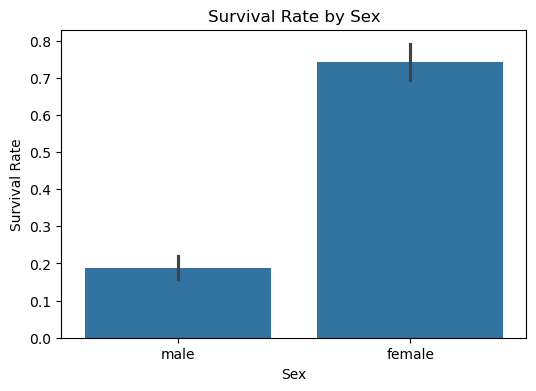

In [8]:
plt.figure(figsize=(6,4))
sns.barplot(data=df, x='Sex', y='Survived')
plt.title('Survival Rate by Sex')
plt.ylabel('Survival Rate')
plt.show()

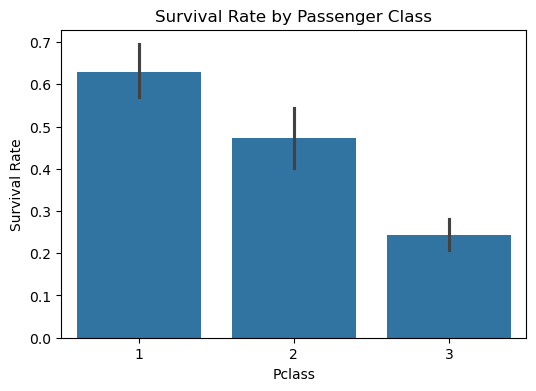

In [9]:
plt.figure(figsize=(6,4))
sns.barplot(data=df, x='Pclass', y='Survived')
plt.title('Survival Rate by Passenger Class')
plt.ylabel('Survival Rate')
plt.show()

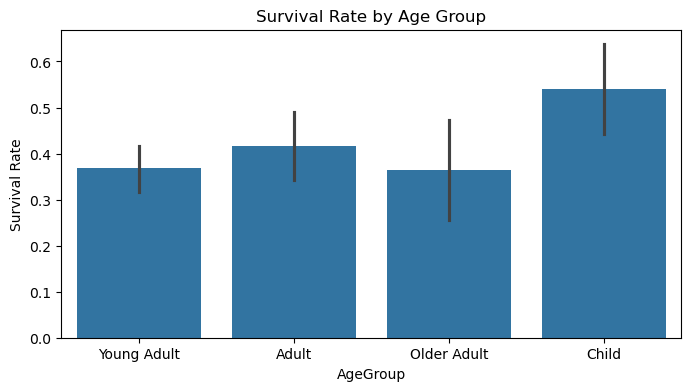

In [10]:
plt.figure(figsize=(8,4))
sns.barplot(data=df, x='AgeGroup', y='Survived')
plt.title('Survival Rate by Age Group')
plt.ylabel('Survival Rate')
plt.show()

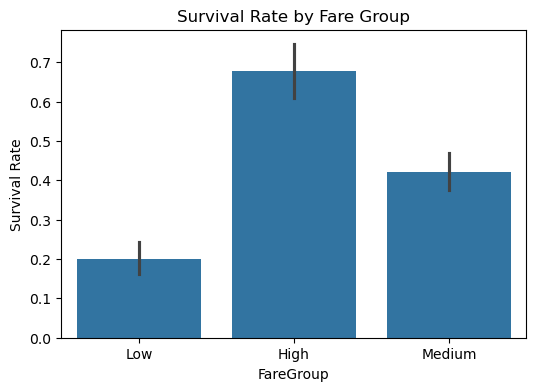

In [11]:
plt.figure(figsize=(6,4))
sns.barplot(data=df, x='FareGroup', y='Survived')
plt.title('Survival Rate by Fare Group')
plt.ylabel('Survival Rate')
plt.show()

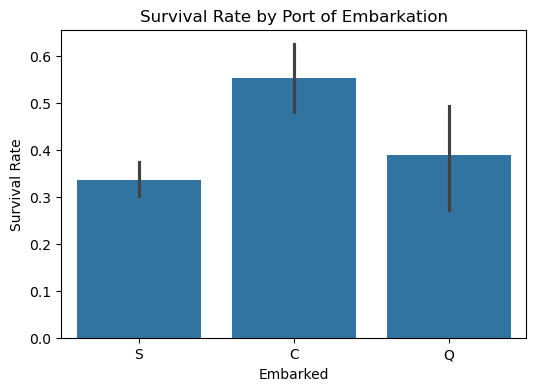

In [12]:
plt.figure(figsize=(6,4))
sns.barplot(data=df, x='Embarked', y='Survived')
plt.title('Survival Rate by Port of Embarkation')
plt.ylabel('Survival Rate')
plt.show()

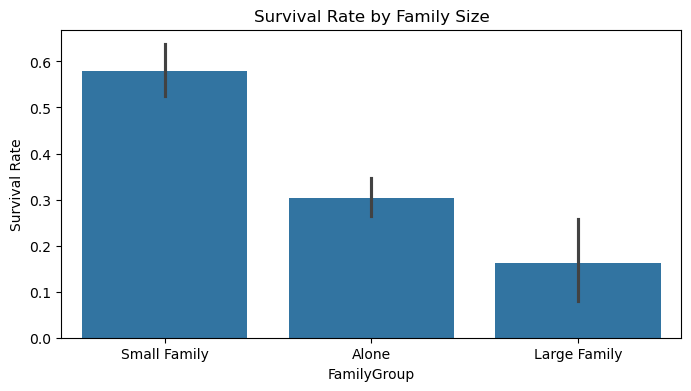

In [14]:
plt.figure(figsize=(8,4))
sns.barplot(data=df, x='FamilyGroup', y='Survived')
plt.title('Survival Rate by Family Size')
plt.ylabel('Survival Rate')
plt.show()

In [ ]:
Passenger 1
Alexandria Humphrey
Age - 25
Sex - Female
Passenger Class - 1st Class
Fare - 60
Travel Companions - Only her spouse and brother
Port of Departure - Cherbourg

Female passengers had a higher survival rate due to priority of lifeboats. 
First-class were closer to the upper deck.
Passengers with higher fares had higher survival percentages. 
Smaller family groups were easier moved and quickly moved during evacuation than larger groups. 
Those who embarked from Cherbourg had a higher rate of survival.

Thomas Jenkins
Passenger 2
Age - 50
Sex - Male
Passenger Class - 3rd Class
Fare - 9
Travel Companions - Alone
Port of Departure - Southampton


Solo travelers had lower survival rates due to less help.
Lower decks had less access to life boats. 
Older passengers were likely to have mobility issues. 
Third class/low fares had low survival rates. 
Those who embarked from Southampton had the lowest survival rates. 

In [19]:
most_survive = df[
    (df['Sex'] == 'female') &
    (df['Pclass'] == 1) &
    (df['Fare'] >= 50) &
    (df['FamilyGroup'] == 'Small Family') &
    (df['Embarked'] == 'C') &
    (df['Survived'] == 1)
]

most_survive[['Name', 'Age', 'Fare', 'FamilyGroup', 'Embarked']].head()

,Name,Age,Fare,FamilyGroup,Embarked
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,71.2833,Small Family,C
31,"Spencer, Mrs. William Augustus (Marie Eugenie)",NaN,146.5208,Small Family,C
52,"Harper, Mrs. Henry Sleeper (Myna Haxtun)",49.0,76.7292,Small Family,C
215,"Newell, Miss. Madeleine",31.0,113.2750,Small Family,C
291,"Bishop, Mrs. Dickinson H (Helen Walton)",19.0,91.0792,Small Family,C


In [21]:
least_survive = df[
    (df['Sex'] == 'male') &
    (df['Pclass'] == 3) &
    (df['Fare'] < 10) &
    (df['FamilyGroup'] == 'Alone') &
    (df['Embarked'] == 'S') &
    (df['Survived'] == 0) &
    (df['Age']>=50)
]

least_survive[['Name', 'Age', 'Fare', 'FamilyGroup', 'Embarked']].head()

,Name,Age,Fare,FamilyGroup,Embarked
94,"Coxon, Mr. Daniel",59.0,7.2500,Alone,S
152,"Meo, Mr. Alfonzo",55.5,8.0500,Alone,S
222,"Green, Mr. George Henry",51.0,8.0500,Alone,S
326,"Nysveen, Mr. Johan Hansen",61.0,6.2375,Alone,S
406,"Widegren, Mr. Carl/Charles Peter",51.0,7.7500,Alone,S


In [ ]:
Most likely to survive: Mrs. John Bradley Cumings(Florence Briggs Cumings)
Least likely to survive: Mr. Daniel Coxon

From https://www.encyclopedia-titanica.org/titanic-survivor/florence-briggs-cumings.html
Mrs. Cumings survived but her husband died when the ship sank. His body was not recovered. She held onto hope that her husband had somehow survived. 

From https://www.encyclopedia-titanica.org/titanic-victim/daniel-coxon.html
Mr. Coxon was alone and described as a laboror and a cripple, having a paralyzed arm. 


In [ ]:
The characteristics of both of these characters fit the description of the ficticious characters. They also match the characteristics of
the visualizations. 